###Research Question

Which lifestyle factors are most strongly associated with Alzheimer's diagnosis, and do these associations differ between individuals with and without a family history of Alzheimer's disease?

In [50]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/yhq2gr/Alzheimers-and-Physical-Activity/refs/heads/main/alzheimers_disease_data.csv")

print("Shape of dataset:", df.shape)
df.head()

df.info()
df.isnull().sum()
df = df.drop(columns=['DoctorInCharge'])
#data summary and check for missing values
#drops column we will not be using

Shape of dataset: (2149, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes           

In [72]:
features = ['PhysicalActivity', 'DietQuality', 'SleepQuality', 'BMI', 'AlcoholConsumption']
#split dataset by family history
fh_yes = df[df['FamilyHistoryAlzheimers'] == 1]
fh_no = df[df['FamilyHistoryAlzheimers'] == 0]

#counters
strong_yes = 0
strong_no = 0

#threshold for "strong" relationship
threshold = 0.4

for col in features:
    #correlation for each group
    corr_yes = fh_yes[col].corr(fh_yes['Diagnosis'])
    corr_no = fh_no[col].corr(fh_no['Diagnosis'])

    #update counters
    if abs(corr_yes) > threshold:
        strong_yes += 1

    if abs(corr_no) > threshold:
        strong_no += 1

print("Strong predictors (family history = YES):", strong_yes)
print("Strong predictors (family history = NO):", strong_no)
# This loop iterates over selected lifestyle features and counts how many
# have a strong correlation with Alzheimer's diagnosis (absolute value > 0.4).
# The counts are tracked separately for individuals with and without a family history,
# allowing comparison of how many strong predictors exist in each group.

Strong predictors (family history = YES): 0
Strong predictors (family history = NO): 0


In [75]:
# Compute diagnosis rates
rate_yes = fh_yes['Diagnosis'].mean()
rate_no = fh_no['Diagnosis'].mean()

# Conditional comparison of groups
if rate_yes > rate_no:
    print("Higher Alzheimer's diagnosis rate in individuals WITH family history")
elif rate_yes < rate_no:
    print("Higher Alzheimer's diagnosis rate in individuals WITHOUT family history")
else:
    print("Diagnosis rates are equal between groups")

print("Family history = YES rate:", rate_yes)
print("Family history = NO rate:", rate_no)
# This conditional logic compares the proportion of Alzheimer's diagnoses
# between individuals with and without a family history. It determines which
# group has a higher diagnosis rate, helping assess whether family history
# is associated with increased risk.

Higher Alzheimer's diagnosis rate in individuals WITHOUT family history
Family history = YES rate: 0.32656826568265684
Family history = NO rate: 0.3627878033602987


In [76]:
def strongest_lifestyle_factor(data, features, dx):
    """
    Finds the lifestyle feature with the strongest correlation to diagnosis.

    Parameters:
    data (DataFrame): dataset
    features (list): list of lifestyle feature column names
    dx (str): Diagnosis column

    Returns:
    tuple: (feature name, correlation value)
    """

    best_feature = None
    best_corr = 0

    for col in features:
        corr = data[col].corr(data[dx])

        #compare absolute correlation strength
        if abs(corr) > abs(best_corr):
            best_corr = corr
            best_feature = col

    return best_feature, best_corr
features = ['PhysicalActivity', 'DietQuality', 'SleepQuality', 'BMI', 'AlcoholConsumption']

# All patients
print("All patients:", strongest_lifestyle_factor(df, features, 'Diagnosis'))

# With family history
print("Family history = YES:", strongest_lifestyle_factor(fh_yes, features, 'Diagnosis'))

# Without family history
print("Family history = NO:", strongest_lifestyle_factor(fh_no, features, 'Diagnosis'))
# This function identifies the lifestyle factor most strongly associated with Alzheimer's diagnosis
# by comparing correlation values across features. It is used to determine whether the most important
# predictors differ between individuals with and without a family history.

All patients: ('SleepQuality', np.float64(-0.05654808600710897))
Family history = YES: ('BMI', np.float64(0.029931394921345552))
Family history = NO: ('SleepQuality', np.float64(-0.07645708374604827))


In [79]:
#get strongest feature for all patients
best_feature, best_corr = strongest_lifestyle_factor(df, features, 'Diagnosis')

print("Using feature:", best_feature)
import numpy as np

#convert chosen feature to numpy array
arr = np.array(df[best_feature])

#mean(vectorized)
print(f"Average {best_feature}:", np.mean(arr))

#below average values(boolean)
low_values = arr[arr < np.mean(arr)]
print(f"Number of below-average {best_feature} values:", len(low_values))

#index highest value
max_idx = arr.argmax()
print(f"Maximum {best_feature} value:", arr[max_idx])


Using feature: SleepQuality
Average SleepQuality: 7.051081071923196
Number of below-average SleepQuality values: 1050
Maximum SleepQuality value: 9.99984031668144


In [83]:
groups = {
    "All": df,
    "FamilyHistory_Yes": fh_yes,
    "FamilyHistory_No": fh_no
}

corr_dict = {}

#dictionary
for group_name, data in groups.items():
    corr_dict[group_name] = {}

    for col in features:
        corr = data[col].corr(data['Diagnosis'])
        corr_dict[group_name][col] = corr

print(corr_dict)

for group_name in corr_dict:
    group_data = corr_dict[group_name]

    def absval(feature):
        return abs(group_data[feature])

    best_feature = max(group_data, key=key_func)

    print(group_name)
    print("Strongest feature:", best_feature)
    print("Correlation:", group_data[best_feature])
    print()
# A dictionary was created to store correlation results for each lifestyle feature
# across different groups (all patients, with family history, without family history).
# We then use the dictionary to identify the strongest predictor in each group,
# allowing comparison of how associations differ between groups.

{'All': {'PhysicalActivity': np.float64(0.005945042453086607), 'DietQuality': np.float64(0.008505771333395024), 'SleepQuality': np.float64(-0.05654808600710897), 'BMI': np.float64(0.026342813028880006), 'AlcoholConsumption': np.float64(-0.007617968445114159)}, 'FamilyHistory_Yes': {'PhysicalActivity': np.float64(-0.0019257270778155647), 'DietQuality': np.float64(0.008624240007365594), 'SleepQuality': np.float64(0.008542688424153799), 'BMI': np.float64(0.029931394921345552), 'AlcoholConsumption': np.float64(0.017277215083166615)}, 'FamilyHistory_No': {'PhysicalActivity': np.float64(0.007961894086199132), 'DietQuality': np.float64(0.007987834519004028), 'SleepQuality': np.float64(-0.07645708374604827), 'BMI': np.float64(0.025463833035357066), 'AlcoholConsumption': np.float64(-0.01638877748948951)}}
All
Strongest feature: SleepQuality
Correlation: -0.05654808600710897

FamilyHistory_Yes
Strongest feature: BMI
Correlation: 0.029931394921345552

FamilyHistory_No
Strongest feature: SleepQual

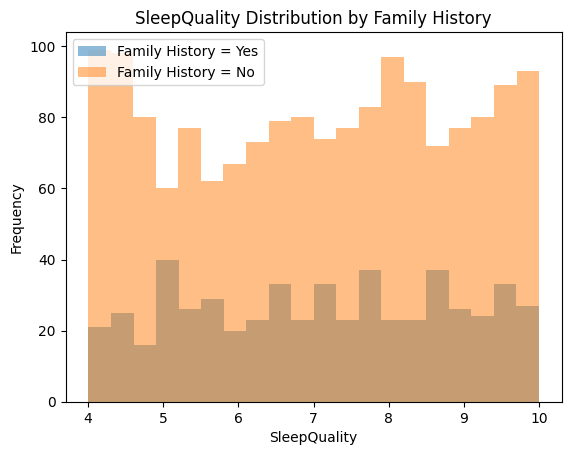

In [69]:
plt.hist(fh_yes[best_feature], bins=20, alpha=0.5, label='Family History = Yes')
plt.hist(fh_no[best_feature], bins=20, alpha=0.5, label='Family History = No')

plt.title(f"{best_feature} Distribution by Family History")
plt.xlabel(best_feature)
plt.ylabel("Frequency")
plt.legend()
plt.show()
# This histogram shows the distribution of the strongest lifestyle feature identified earlier.
# The distribution appears irregular and not normally distributed.
# The values are spread across the range without a clear peak,
# indicating no strong concentration around a central value.

/tmp/ipykernel_10646/651246201.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group1, group3, group2, group4],


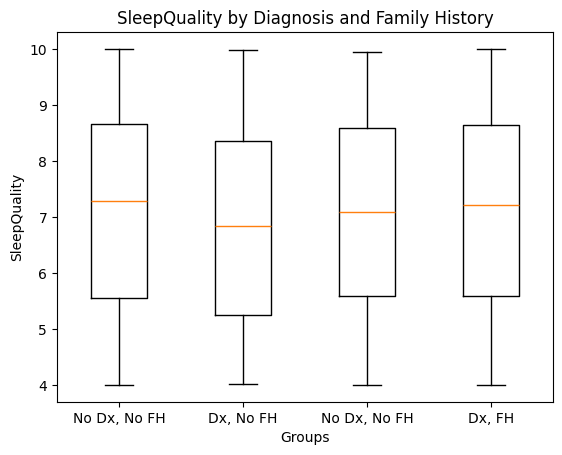

In [68]:
# Create grouped data
group1 = df[(df['Diagnosis'] == 0) & (df['FamilyHistoryAlzheimers'] == 0)][best_feature]
group2 = df[(df['Diagnosis'] == 0) & (df['FamilyHistoryAlzheimers'] == 1)][best_feature]
group3 = df[(df['Diagnosis'] == 1) & (df['FamilyHistoryAlzheimers'] == 0)][best_feature]
group4 = df[(df['Diagnosis'] == 1) & (df['FamilyHistoryAlzheimers'] == 1)][best_feature]

plt.boxplot([group1, group3, group2, group4],
            labels=['No Dx, No FH', 'Dx, No FH', 'No Dx, No FH', 'Dx, FH'])

plt.title(f"{best_feature} by Diagnosis and Family History")
plt.xlabel("Groups")
plt.ylabel(best_feature)
plt.show()
# A box plot was used to compare the distribution of the strongest lifestyle feature
# across four groups defined by diagnosis and family history.
# This helps visualize whether the feature differs between diagnosed and non-diagnosed
# individuals and whether family history influences this relationship.

In [70]:
from sklearn.linear_model import LinearRegression

# Use same lifestyle features
X = df[features]
y = df['Diagnosis']

model = LinearRegression()
model.fit(X, y)

r2_all = model.score(X, y)

print("R^2 (all patients):", r2_all)

# Family history = YES
X_yes = fh_yes[features]
y_yes = fh_yes['Diagnosis']

model_yes = LinearRegression()
model_yes.fit(X_yes, y_yes)

r2_yes = model_yes.score(X_yes, y_yes)

# Family history = NO
X_no = fh_no[features]
y_no = fh_no['Diagnosis']

model_no = LinearRegression()
model_no.fit(X_no, y_no)

r2_no = model_no.score(X_no, y_no)

print("R^2 (family history = YES):", r2_yes)
print("R^2 (family history = NO):", r2_no)

# Although the model shows slightly higher R^2 for individuals without a family history,
# the values are near zero for both groups, indicating that lifestyle factors have minimal predictive power overall.

R^2 (all patients): 0.004088456417597142
R^2 (family history = YES): 0.0013863337681008225
R^2 (family history = NO): 0.006942389243403402


### Final Conclusion

This analysis examined which lifestyle factors are associated with Alzheimer's diagnosis and whether these relationships differ based on family history. Across all lifestyle variables considered, correlations with diagnosis were extremely weak, indicating little to no direct association.

The strongest lifestyle factors identified (such as SleepQuality and BMI) showed only minimal relationships with diagnosis, and these patterns were consistent across both groups with and without a family history of Alzheimer's.

Linear regression results confirmed these observations, with R^2 values near zero for all groups. Although the model showed slightly higher predictive power for individuals without a family history, this difference was negligible and does not meaningfully change the overall conclusion.

Overall, the results suggest that lifestyle factors alone are not strong predictors of Alzheimer's diagnosis in this dataset.